# 05 — Latent regression model of turnout (PLS)

This is the priority notebook in the rewrite: it fits the **partial least squares (PLS) latent-variable regression** that the earlier, much larger exploration (dozens of scripts under the archived `modelling/dimension_reduction/` tree) eventually converged on as the preferred way to summarize what drives CT-level voter turnout in Toronto.

**Why PLS, briefly:** the predictor blocks (demographics, housing, immigration/citizenship, electoral competitiveness, transportation) are highly collinear with each other — e.g. renters, apartment share, and population density all move together. Ordinary regression on all of them at once is unstable. PLS instead extracts a small number of *components* — linear combinations of the predictors — chosen specifically to covary with turnout, so we get a handful of interpretable "social-geography axes" instead of 14 shaky individual coefficients.

**What's in this notebook:**
1. Load the model-input table built in `04_build_feature_table_and_model_input.ipynb`.
2. A **predictor list you can edit** (`PREDICTORS` in the constants cell) — swap it out to try a different theory-driven variable set without touching any other code.
3. The PLS fitting algorithm itself (NIPALS), ported faithfully from the archived `run_dimension_reduction_workflow.py` / `run_meeting_pls.py` so results are directly comparable to the earlier work.
4. Cross-validated component selection, variable importance (VIP), and component loadings.
5. Plain-language interpretation of each retained component, plus "reference geographies" — the real CTs that sit at each extreme.
6. A verification check against the archived `meeting_pls_*` outputs.

The default `PREDICTORS` list below is the exact 14-variable set the earlier work landed on (nicknamed "the meeting PLS" in the archive, because it was the compact version presented in a research meeting). Everything downstream is generic to whatever predictor list you put in that cell.

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)


In [2]:
# --- Paths -------------------------------------------------------------
REPO_ROOT = Path.cwd().resolve().parents[1]
INPUT_PATH = REPO_ROOT / "data/toronto_election_turnout/features/ct_model_input.csv"
OUTPUT_ROOT = REPO_ROOT / "data/toronto_election_turnout/model"

# Archived ground truth, read-only, used only in the verification section at the end.
ARCHIVE_MODEL_ROOT = REPO_ROOT / "data/toronto_election_turnout/archive/modelling/processed/dimension_reduction/meeting_PLS/meeting_pls_model"

# --- Target and predictors ----------------------------------------------
TARGET = "outcome_mean_participation_citizen_18plus"

# Edit this list to try a different theory-driven predictor set. Everything
# below this cell is generic to whatever columns you put here (they must
# exist in ct_model_input.csv).
PREDICTORS = [
    "block1_age_18_34_share",
    "block1_age_65_plus_share",
    "block1_average_household_size",
    "block1_bachelors_or_higher_25_64_share",
    "block1_low_income_lim_at_share",
    "block2_renter_share",
    "block2_same_address_5yr_share",
    "block2_apartment_share",
    "block2_condo_share",
    "block2_population_density_per_km2",
    "block3_citizen_adult_share",
    "block3_immigrant_share",
    "block3_visible_minority_share",
    "block5_tts_no_car_household_share",
]

# --- PLS fitting parameters (match the archived run exactly, for comparability) ---
MAX_COMPONENTS = 12
CV_FOLDS = 10
RANDOM_SEED = 20260803

# --- Cosmetic lookups, used only for readable output/plots, never for fitting ---
PLAIN_VARIABLE_NAMES = {
    "block1_age_18_34_share": "age 18 to 34 share",
    "block1_age_35_64_share": "age 35 to 64 share",
    "block1_age_65_plus_share": "age 65 plus share",
    "block1_median_age": "median age",
    "block1_average_household_size": "average household size",
    "block1_bachelors_or_higher_25_64_share": "bachelor or higher education share",
    "block1_low_income_lim_at_share": "low income share",
    "block1_unemployment_rate_share": "unemployment rate",
    "block2_renter_share": "renter share",
    "block2_owner_share": "owner share",
    "block2_same_address_1yr_share": "same address one year share",
    "block2_same_address_5yr_share": "same address five year share",
    "block2_condo_share": "condo share",
    "block2_apartment_share": "apartment share",
    "block2_detached_share": "detached house share",
    "block2_semi_detached_share": "semi detached house share",
    "block2_population_density_per_km2": "population density",
    "block3_immigrant_share": "immigrant share",
    "block3_recent_immigrant_share": "recent immigrant share",
    "block3_non_citizen_share": "non citizen share",
    "block3_citizen_adult_share": "citizen adult share",
    "block3_visible_minority_share": "visible minority share",
    "block3_english_french_knowledge_share": "English or French knowledge share",
    "block3_non_official_mother_tongue_share": "non official mother tongue share",
    "block4_mayoral_top_two_margin": "mayoral top two margin",
    "block4_effective_mayoral_candidates_5pct": "effective mayoral candidates above five percent",
    "block4_mayoral_vote_fragmentation": "mayoral vote fragmentation",
    "block4_federal_margin": "federal margin",
    "block4_provincial_margin": "provincial margin",
    "block5_transit_commute_share_preferred": "transit commute share",
    "block5_no_car_household_share": "no car household share",
    "block5_tts_no_car_household_share": "TTS no car household share",
    "block5_tts_transit_trip_share": "TTS transit trip share",
    "block5_social_housing_share": "social housing share",
    "block5_requests_311_per_1000": "311 requests per 1000 residents",
    "block5_library_access_1200m": "library access within 1200 metres",
    "block5_community_centre_access_1200m": "community centre access within 1200 metres",
    "block5_park_access_1200m": "park access within 1200 metres",
    "block5_shelter_access_1200m": "shelter access within 1200 metres",
    "block5_school_age_5_17_share": "school age children share",
    "block5_ksi_collision_events_2021_2025_per_1000": "KSI collisions per 1000 residents",
    "block5_development_applications_2021_2025_per_1000": "development applications per 1000 residents",
}

FAMILIES = {
    "age_structure": ["block1_age_18_34_share", "block1_age_35_64_share", "block1_age_65_plus_share", "block1_median_age"],
    "household_class": ["block1_average_household_size", "block1_bachelors_or_higher_25_64_share", "block1_low_income_lim_at_share", "block1_unemployment_rate_share"],
    "housing_tenure": ["block2_renter_share", "block2_owner_share"],
    "residential_stability": ["block2_same_address_1yr_share", "block2_same_address_5yr_share"],
    "housing_form_density": ["block2_condo_share", "block2_apartment_share", "block2_detached_share", "block2_semi_detached_share", "block2_population_density_per_km2"],
    "immigration_citizenship": ["block3_immigrant_share", "block3_recent_immigrant_share", "block3_non_citizen_share", "block3_citizen_adult_share", "block3_visible_minority_share", "block3_english_french_knowledge_share", "block3_non_official_mother_tongue_share"],
    "mayoral_competitiveness": ["block4_mayoral_top_two_margin", "block4_mayoral_winner_margin", "block4_effective_mayoral_candidates_5pct", "block4_mayoral_candidate_count_5pct", "block4_mayoral_vote_fragmentation"],
    "federal_competitiveness": ["block4_federal_margin", "block4_effective_federal_parties_5pct", "block4_federal_party_count_5pct", "block4_federal_vote_fragmentation"],
    "provincial_competitiveness": ["block4_provincial_margin", "block4_effective_provincial_parties_5pct", "block4_provincial_party_count_5pct", "block4_provincial_vote_fragmentation"],
    "transportation_access": ["block5_transit_commute_share_preferred", "block5_no_car_household_share", "block5_tts_no_car_household_share", "block5_tts_transit_trip_share"],
    "service_access": ["block5_library_access_1200m", "block5_community_centre_access_1200m", "block5_park_access_1200m", "block5_shelter_access_1200m"],
    "service_contact": ["block5_social_housing_share", "block5_requests_311_per_1000", "block5_ksi_collision_events_2021_2025_per_1000", "block5_development_applications_2021_2025_per_1000", "block5_school_age_5_17_share"],
}


def plain_name(variable: str) -> str:
    return PLAIN_VARIABLE_NAMES.get(variable, variable.replace("_", " "))


def variable_family(variable: str) -> str:
    for family, members in FAMILIES.items():
        if variable in members:
            return family
    return "other"


OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


## Load the model-input table

This is the 585-CT feature table built in notebook 04 — Blocks 1–5 joined, median-imputed. We just check that the predictors and target we asked for are actually present and finite.

In [3]:
df = pd.read_csv(INPUT_PATH)
print(f"Loaded {len(df)} CTs, {df.shape[1]} columns from {INPUT_PATH.relative_to(REPO_ROOT)}")

missing = [v for v in PREDICTORS if v not in df.columns]
if missing:
    raise ValueError(f"Missing predictors in ct_model_input.csv: {missing}")
if TARGET not in df.columns:
    raise ValueError(f"Missing target column: {TARGET}")

x_all = df[PREDICTORS].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
y_all = pd.to_numeric(df[TARGET], errors="coerce").to_numpy(dtype=float)
keep = np.isfinite(y_all) & np.isfinite(x_all).all(axis=1)
print(f"{keep.sum()} of {len(df)} CTs have complete data on all {len(PREDICTORS)} predictors + target")

x = x_all[keep]
y = y_all[keep]
df_model = df.loc[keep].reset_index(drop=True)


Loaded 585 CTs, 156 columns from data/toronto_election_turnout/features/ct_model_input.csv
585 of 585 CTs have complete data on all 14 predictors + target


## The PLS algorithm (NIPALS)

We fit PLS1 (single outcome) using the NIPALS algorithm, ported directly from the archived workflow so results are numerically comparable to the earlier analysis:

1. Standardize `x` and `y` to mean 0 / std 1 (population std, `ddof=0`; a zero-variance predictor gets `std=1` so it doesn't blow up).
2. Each component: find the weight vector `w` most aligned with `x.T @ y` (i.e. the direction in predictor-space that best covaries with the outcome), project `x` onto it to get scores `t`, then **deflate** both `x` and `y` by removing what that component explains, before extracting the next one.
3. Repeat until we hit the requested number of components, `x` runs out of predictors, or a component's signal drops to numerical zero (nothing left to extract).

This is the same idea as PCA, except each component is chosen to explain the outcome, not just the predictors' own variance — that's what makes it a *supervised* dimension reduction, and why we call the resulting components "latent variables driving turnout" rather than just "latent variables in the predictor set."

In [4]:
@dataclass
class PlsModel:
    x_mean: np.ndarray
    x_std: np.ndarray
    y_mean: float
    y_std: float
    weights: np.ndarray
    loadings: np.ndarray
    q: np.ndarray
    scores: np.ndarray
    coef_scaled: np.ndarray
    vip: np.ndarray


def standardize_train(x: np.ndarray, y: np.ndarray):
    x_mean = np.nanmean(x, axis=0)
    x_std = np.nanstd(x, axis=0, ddof=0)
    x_std[x_std == 0] = 1
    y_mean = float(np.nanmean(y))
    y_std = float(np.nanstd(y, ddof=0)) or 1.0
    return (x - x_mean) / x_std, (y - y_mean) / y_std, x_mean, x_std, y_mean, y_std


def fit_pls(x: np.ndarray, y: np.ndarray, n_components: int) -> PlsModel:
    xs, ys, x_mean, x_std, y_mean, y_std = standardize_train(x, y)
    x_def = xs.copy()
    y_def = ys.copy()
    n, p = xs.shape
    comps = min(n_components, p, n - 1)
    weights = np.zeros((p, comps))
    loadings = np.zeros((p, comps))
    q = np.zeros(comps)
    scores = np.zeros((n, comps))
    ssy = np.zeros(comps)
    for comp in range(comps):
        w = x_def.T @ y_def
        norm = np.linalg.norm(w)
        if norm < 1e-12:
            weights, loadings, q, scores, ssy = weights[:, :comp], loadings[:, :comp], q[:comp], scores[:, :comp], ssy[:comp]
            break
        w = w / norm
        t = x_def @ w
        tt = float(t.T @ t)
        if tt < 1e-12:
            break
        p_load = (x_def.T @ t) / tt
        q_load = float((y_def.T @ t) / tt)
        x_def = x_def - np.outer(t, p_load)
        y_def = y_def - q_load * t
        weights[:, comp] = w
        loadings[:, comp] = p_load
        q[comp] = q_load
        scores[:, comp] = t
        ssy[comp] = (q_load**2) * tt

    if weights.shape[1] == 0:
        coef_scaled = np.zeros(p)
        vip = np.zeros(p)
    else:
        w_star = weights @ np.linalg.pinv(loadings.T @ weights)
        coef_scaled = w_star @ q
        total_ssy = float(ssy.sum()) or 1.0
        vip = np.sqrt(p * ((weights**2) @ ssy) / total_ssy)
    return PlsModel(x_mean, x_std, y_mean, y_std, weights, loadings, q, scores, coef_scaled, vip)


def predict_pls(model: PlsModel, x: np.ndarray) -> np.ndarray:
    xs = (x - model.x_mean) / model.x_std
    return (xs @ model.coef_scaled) * model.y_std + model.y_mean


## Choosing how many components to keep

More components always fit the *training* data better, so we can't pick the count from training R² alone — that would overfit. Instead we try every component count from 1 to `MAX_COMPONENTS`, and for each one run 10-fold cross-validation (`CV_FOLDS` shuffled folds, fixed random seed for reproducibility) to see how well it predicts held-out CTs. We keep the count with the lowest CV RMSE (ties broken toward the simpler, fewer-component model).

In [5]:
def metrics(y: np.ndarray, pred: np.ndarray, k: int) -> dict[str, float]:
    resid = y - pred
    sse = float(np.sum(resid**2))
    sst = float(np.sum((y - np.mean(y)) ** 2))
    r2 = 1 - sse / sst if sst else 0.0
    n = len(y)
    adj = 1 - (1 - r2) * (n - 1) / max(n - k - 1, 1)
    rmse = math.sqrt(sse / n)
    return {"r2": r2, "adjusted_r2": adj, "rmse": rmse}


def cv_predictions(x: np.ndarray, y: np.ndarray, n_components: int) -> np.ndarray:
    rng = np.random.default_rng(RANDOM_SEED)
    indices = np.arange(len(y))
    rng.shuffle(indices)
    folds = np.array_split(indices, CV_FOLDS)
    pred = np.zeros_like(y, dtype=float)
    for fold in folds:
        train = np.setdiff1d(indices, fold, assume_unique=False)
        model = fit_pls(x[train], y[train], n_components)
        pred[fold] = predict_pls(model, x[fold])
    return pred


def choose_components(x: np.ndarray, y: np.ndarray, max_components: int) -> pd.DataFrame:
    rows = []
    max_comps = min(max_components, x.shape[1], x.shape[0] - 2)
    for comp in tqdm(range(1, max_comps + 1), desc="Components tried"):
        model = fit_pls(x, y, comp)
        train_pred = predict_pls(model, x)
        cv_pred = cv_predictions(x, y, comp)
        train = metrics(y, train_pred, comp)
        cv = metrics(y, cv_pred, comp)
        rows.append({
            "n_components": comp,
            "train_r2": train["r2"],
            "train_adjusted_r2": train["adjusted_r2"],
            "train_rmse": train["rmse"],
            "cv_r2": cv["r2"],
            "cv_rmse": cv["rmse"],
        })
    return pd.DataFrame(rows)


component_cv = choose_components(x, y, MAX_COMPONENTS)
best_n_components = int(component_cv.sort_values(["cv_rmse", "n_components"]).iloc[0]["n_components"])
print(f"Selected {best_n_components} component(s) by cross-validated RMSE")
component_cv


Components tried:   0%|          | 0/12 [00:00<?, ?it/s]

Selected 2 component(s) by cross-validated RMSE


,n_components,train_r2,train_adjusted_r2,train_rmse,cv_r2,cv_rmse
0,1,0.518211,0.517385,0.060336,0.499024,0.061526
1,2,0.561447,0.559940,0.057565,0.533754,0.059355
2,3,0.564812,0.562565,0.057344,0.526613,0.059807
3,4,0.579239,0.576337,0.056385,0.524127,0.059964
4,5,0.582205,0.578597,0.056186,0.527033,0.059781
5,6,0.584829,0.580520,0.056009,0.528629,0.059680
6,7,0.586345,0.581326,0.055907,0.527834,0.059730
7,8,0.588156,0.582436,0.055785,0.528137,0.059711
8,9,0.588193,0.581747,0.055782,0.527331,0.059762
9,10,0.588204,0.581030,0.055781,0.528393,0.059695


## Fit the final model and compute variable importance

With the component count fixed, we refit on the full sample. Two diagnostics per predictor:

- **VIP (variable importance in projection)**: how much each predictor contributes across all retained components, weighted by how much outcome-variance each component explains. VIP > 1 is the usual rule-of-thumb cutoff for "this predictor is pulling its weight."
- **PLS coefficient** (rescaled back to raw units) and its **sign**: whether higher values of that predictor push the model toward higher or lower predicted turnout, holding the fitted components fixed.

We also report each predictor's plain bivariate correlation with turnout, since VIP/coefficient can occasionally disagree with the raw correlation once collinearity is accounted for — that disagreement is itself informative.

In [6]:
model = fit_pls(x, y, best_n_components)
train_pred = predict_pls(model, x)
train_fit = metrics(y, train_pred, best_n_components)
cv_pred = cv_predictions(x, y, best_n_components)
cv_fit = metrics(y, cv_pred, best_n_components)

model_summary = pd.DataFrame([{
    "n": len(y),
    "num_predictors": len(PREDICTORS),
    "selected_components": best_n_components,
    "train_r2": train_fit["r2"],
    "train_adjusted_r2": train_fit["adjusted_r2"],
    "train_rmse": train_fit["rmse"],
    "cv_r2": cv_fit["r2"],
    "cv_rmse": cv_fit["rmse"],
}])
print(f"Train R^2 = {train_fit['r2']:.3f}   CV R^2 = {cv_fit['r2']:.3f}   CV RMSE = {cv_fit['rmse']:.4f}")
model_summary


Train R^2 = 0.561   CV R^2 = 0.534   CV RMSE = 0.0594


,n,num_predictors,selected_components,train_r2,train_adjusted_r2,train_rmse,cv_r2,cv_rmse
0,585,14,2,0.561447,0.55994,0.057565,0.533754,0.059355


In [7]:
coef_raw = model.coef_scaled * model.y_std / model.x_std
turnout_corr = [float(np.corrcoef(x[:, i], y)[0, 1]) for i in range(x.shape[1])]

importance = pd.DataFrame([
    {
        "variable": var,
        "plain_name": plain_name(var),
        "family": variable_family(var),
        "turnout_corr": turnout_corr[i],
        "abs_turnout_corr": abs(turnout_corr[i]),
        "vip": model.vip[i],
        "pls_coefficient": coef_raw[i],
        "direction": "higher turnout" if coef_raw[i] > 0 else "lower turnout",
    }
    for i, var in enumerate(PREDICTORS)
]).sort_values(["vip", "abs_turnout_corr"], ascending=False).reset_index(drop=True)

importance.to_csv(OUTPUT_ROOT / "meeting_pls_variable_importance.csv", index=False)
model_summary.to_csv(OUTPUT_ROOT / "meeting_pls_summary.csv", index=False)
component_cv.to_csv(OUTPUT_ROOT / "meeting_pls_component_cv.csv", index=False)

importance[["plain_name", "family", "vip", "pls_coefficient", "direction", "turnout_corr"]]


,plain_name,family,vip,pls_coefficient,direction,turnout_corr
0,visible minority share,immigration_citizenship,1.836705,-8.104446e-02,lower turnout,-0.641717
1,immigrant share,immigration_citizenship,1.661165,-9.612806e-02,lower turnout,-0.573268
2,bachelor or higher education share,household_class,1.585116,9.960482e-02,higher turnout,0.553836
3,average household size,household_class,1.396658,-3.593670e-02,lower turnout,-0.485368
4,citizen adult share,immigration_citizenship,1.025327,8.707576e-02,higher turnout,0.352900
5,age 65 plus share,age_structure,0.819239,1.955111e-01,higher turnout,0.181889
6,age 18 to 34 share,age_structure,0.680889,-1.514621e-01,lower turnout,-0.136392
7,low income share,household_class,0.620664,-3.821469e-02,lower turnout,-0.199079
8,TTS no car household share,transportation_access,0.536439,2.077644e-02,higher turnout,0.181640
9,same address five year share,residential_stability,0.408143,-1.658357e-03,lower turnout,-0.119719


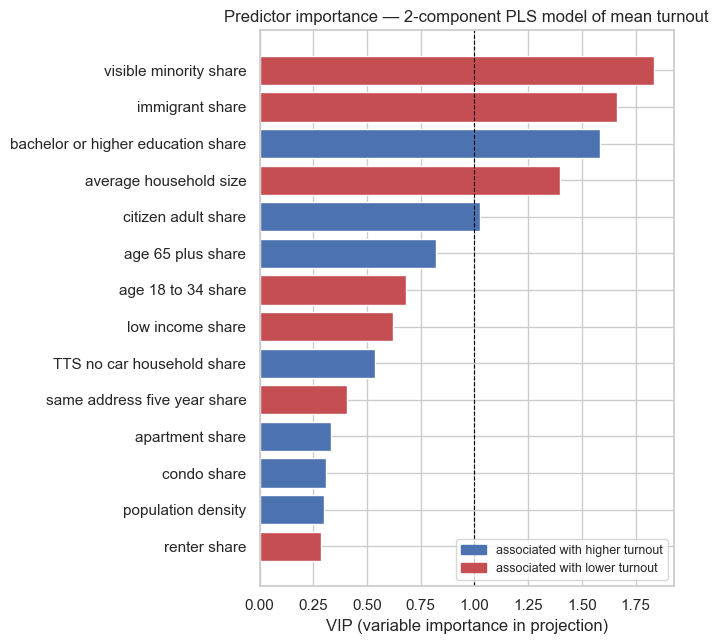

In [8]:
fig, ax = plt.subplots(figsize=(7, 0.4 * len(PREDICTORS) + 1))
plot_df = importance.sort_values("vip")
colors = ["#4C72B0" if d == "higher turnout" else "#C44E52" for d in plot_df["direction"]]
ax.barh(plot_df["plain_name"], plot_df["vip"], color=colors)
ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("VIP (variable importance in projection)")
ax.set_title(f"Predictor importance — {best_n_components}-component PLS model of mean turnout")
handles = [plt.Rectangle((0, 0), 1, 1, color="#4C72B0"), plt.Rectangle((0, 0), 1, 1, color="#C44E52")]
ax.legend(handles, ["associated with higher turnout", "associated with lower turnout"], loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


## Component loadings and interpretation

Each retained component is a weighted combination of the predictors (the "loadings" below). A predictor with a large positive loading and a predictor with a large negative loading on the *same* component are being placed at opposite ends of the same latent axis — e.g. "younger renters" versus "older homeowners."

This section is written generically so it re-runs sensibly if you change `PREDICTORS`: for each component it lists the predictors ranked by absolute loading, split into the "high side" (positive loading) and "low side" (negative loading), and reports how that component's projected score correlates with actual mean turnout — that correlation is what tells you whether a component is a real turnout gradient or just a secondary descriptive contrast.

*For context:* with the original 14-variable set, the earlier analysis read the first component as "education/resource attachment versus racialized-immigrant household geography" (the strongest, most turnout-correlated axis), and the second as "older residential stability versus younger no-car renter/density geography" (a real but weaker, more descriptive contrast). Component titles like that were hand-written for that specific variable set — this notebook computes the loadings/correlations that would justify a story like that, but leaves the final wording to you once you've looked at the numbers below.

In [9]:
loadings = pd.DataFrame(
    model.loadings,
    index=PREDICTORS,
    columns=[f"component_{i + 1}" for i in range(model.loadings.shape[1])],
).reset_index(names="variable")
loadings.to_csv(OUTPUT_ROOT / "meeting_pls_component_loadings.csv", index=False)

component_cols = [c for c in loadings.columns if c.startswith("component_")]
composition_rows = []
for comp in component_cols:
    tmp = loadings[["variable", comp]].rename(columns={comp: "loading"}).copy()
    tmp["component"] = comp
    tmp["abs_loading"] = tmp["loading"].abs()
    tmp["plain_name"] = tmp["variable"].map(plain_name)
    tmp["family"] = tmp["variable"].map(variable_family)
    tmp = tmp.merge(importance[["variable", "vip", "turnout_corr", "direction"]], on="variable", how="left")
    tmp["side"] = np.where(tmp["loading"] >= 0, "high side", "low side")
    tmp = tmp.sort_values("abs_loading", ascending=False)
    composition_rows.append(tmp)
composition = pd.concat(composition_rows, ignore_index=True)
composition.to_csv(OUTPUT_ROOT / "meeting_pls_component_composition.csv", index=False)

# Each component's own turnout correlation, using a simple standardized projection.
component_turnout_corr = {}
for comp in component_cols:
    group = composition[composition["component"] == comp]
    vars_in_comp = group["variable"].tolist()
    weights = group.set_index("variable")["loading"]
    z = (df_model[vars_in_comp] - df_model[vars_in_comp].mean()) / df_model[vars_in_comp].std(ddof=0)
    score = z.fillna(0).to_numpy() @ weights.loc[vars_in_comp].to_numpy()
    component_turnout_corr[comp] = float(np.corrcoef(score, df_model[TARGET])[0, 1])

for comp in component_cols:
    group = composition[composition["component"] == comp]
    corr = component_turnout_corr[comp]
    direction = "a direct higher-turnout axis" if corr > 0.20 else "a direct lower-turnout axis" if corr < -0.20 else "a secondary descriptive contrast, not strongly tied to turnout"
    high = group[group["side"] == "high side"]["plain_name"].head(4).tolist()
    low = group[group["side"] == "low side"]["plain_name"].head(4).tolist()
    print(f"{comp} (turnout correlation = {corr:+.2f}, read as {direction}):")
    print(f"  high side: {', '.join(high)}")
    print(f"  low side:  {', '.join(low)}")
    print()

composition[["component", "plain_name", "family", "side", "loading", "vip", "turnout_corr", "direction"]]


component_1 (turnout correlation = +0.69, read as a direct higher-turnout axis):
  high side: bachelor or higher education share, citizen adult share, TTS no car household share, population density
  low side:  visible minority share, immigrant share, average household size, low income share

component_2 (turnout correlation = +0.00, read as a secondary descriptive contrast, not strongly tied to turnout):
  high side: age 65 plus share, same address five year share, immigrant share, low income share
  low side:  age 18 to 34 share, TTS no car household share, renter share, population density



,component,plain_name,family,side,loading,vip,turnout_corr,direction
0,component_1,visible minority share,immigration_citizenship,low side,-0.515577,1.836705,-0.641717,lower turnout
1,component_1,immigrant share,immigration_citizenship,low side,-0.502267,1.661165,-0.573268,lower turnout
2,component_1,bachelor or higher education share,household_class,high side,0.437647,1.585116,0.553836,higher turnout
3,component_1,average household size,household_class,low side,-0.360801,1.396658,-0.485368,lower turnout
4,component_1,citizen adult share,immigration_citizenship,high side,0.312105,1.025327,0.352900,higher turnout
5,component_1,low income share,household_class,low side,-0.201852,0.620664,-0.199079,lower turnout
6,component_1,TTS no car household share,transportation_access,high side,0.167934,0.536439,0.181640,higher turnout
7,component_1,same address five year share,residential_stability,low side,-0.134370,0.408143,-0.119719,lower turnout
8,component_1,population density,housing_form_density,high side,0.068225,0.299153,0.101504,higher turnout
9,component_1,renter share,housing_tenure,low side,-0.035409,0.285473,-0.081174,lower turnout


## Reference geographies

Abstract loadings are easier to trust once you can point at real places. For each component we list the 3 CTs with the highest and lowest projected score — these are the census tracts that most define each end of that latent axis.

In [10]:
reference_rows = []
for comp in component_cols:
    group = composition[composition["component"] == comp]
    vars_in_comp = group["variable"].tolist()
    weights = group.set_index("variable")["loading"]
    z = (df_model[vars_in_comp] - df_model[vars_in_comp].mean()) / df_model[vars_in_comp].std(ddof=0)
    score = z.fillna(0).to_numpy() @ weights.loc[vars_in_comp].to_numpy()
    temp = pd.DataFrame({
        "ct": df_model["geo_name"],
        "component": comp,
        "score": score,
        "mean_turnout": df_model[TARGET],
        "component_turnout_corr": component_turnout_corr[comp],
    })
    reference_rows.append(temp.sort_values("score", ascending=False).head(3).assign(side="high side"))
    reference_rows.append(temp.sort_values("score", ascending=True).head(3).assign(side="low side"))
reference_geographies = pd.concat(reference_rows, ignore_index=True)
reference_geographies.to_csv(OUTPUT_ROOT / "meeting_pls_reference_geographies.csv", index=False)
reference_geographies


,ct,component,score,mean_turnout,component_turnout_corr,side
0,47.03,component_1,3.686902,0.655577,6.922519e-01,high side
1,87.00,component_1,3.432691,0.559576,6.922519e-01,high side
2,102.04,component_1,3.349477,0.538838,6.922519e-01,high side
3,377.06,component_1,-3.915274,0.431509,6.922519e-01,low side
4,194.01,component_1,-3.907467,0.471296,6.922519e-01,low side
5,376.06,component_1,-3.854631,0.979253,6.922519e-01,low side
6,376.06,component_2,11.204711,0.979253,1.092214e-16,high side
7,205.00,component_2,9.267983,0.521123,1.092214e-16,high side
8,6.00,component_2,8.176526,0.521123,1.092214e-16,high side
9,11.02,component_2,-6.259195,0.488602,1.092214e-16,low side


## Verification against the archived model

This check only makes sense while `PREDICTORS` is still the original 14-variable set — if you've edited it above to try something else, skip this cell (there's nothing archived to compare a new predictor set against). With the original set, this notebook should reproduce the archived `meeting_pls_*` outputs almost exactly: same target, same algorithm, same CV seed, and a model-input table that matched the archived one to floating-point noise on 139 of 156 columns (see notebook 04's verification — the couple of columns that differ are documented, small, non-systematic corrections, not implementation drift).

In [11]:
ORIGINAL_PREDICTORS = [
    "block1_age_18_34_share", "block1_age_65_plus_share", "block1_average_household_size",
    "block1_bachelors_or_higher_25_64_share", "block1_low_income_lim_at_share", "block2_renter_share",
    "block2_same_address_5yr_share", "block2_apartment_share", "block2_condo_share",
    "block2_population_density_per_km2", "block3_citizen_adult_share", "block3_immigrant_share",
    "block3_visible_minority_share", "block5_tts_no_car_household_share",
]

if PREDICTORS != ORIGINAL_PREDICTORS:
    print("PREDICTORS has been changed from the original meeting-PLS set — skipping the archived comparison.")
else:
    archived_summary = pd.read_csv(ARCHIVE_MODEL_ROOT / "meeting_pls_summary.csv").iloc[0]
    archived_importance = pd.read_csv(ARCHIVE_MODEL_ROOT / "meeting_pls_variable_importance.csv")
    archived_loadings = pd.read_csv(ARCHIVE_MODEL_ROOT / "meeting_pls_component_loadings.csv")

    print("Component count — ours:", best_n_components, " archived:", int(archived_summary["selected_components"]))
    print(f"CV R^2 — ours: {cv_fit['r2']:.6f}  archived: {archived_summary['cv_r2']:.6f}")
    print(f"Train R^2 — ours: {train_fit['r2']:.6f}  archived: {archived_summary['train_r2']:.6f}")

    vip_check = importance.merge(
        archived_importance[["variable", "vip", "pls_coefficient"]], on="variable", suffixes=("_ours", "_archived")
    )
    vip_check["vip_abs_diff"] = (vip_check["vip_ours"] - vip_check["vip_archived"]).abs()
    print(f"\nMax |VIP difference| across all predictors: {vip_check['vip_abs_diff'].max():.2e}")

    loadings_check = loadings.merge(archived_loadings, on="variable", suffixes=("_ours", "_archived"))
    shared_components = [c for c in component_cols if f"{c}_ours" in loadings_check.columns]
    max_loading_diff = max(
        (loadings_check[f"{c}_ours"] - loadings_check[f"{c}_archived"]).abs().max() for c in shared_components
    )
    print(f"Max |component loading difference|: {max_loading_diff:.2e}")

    status = "PASS" if vip_check["vip_abs_diff"].max() < 0.05 and max_loading_diff < 0.05 else "CHECK — see diffs above"
    print(f"\nVerification: {status}")


Component count — ours: 2  archived: 2
CV R^2 — ours: 0.533754  archived: 0.533657
Train R^2 — ours: 0.561447  archived: 0.561550

Max |VIP difference| across all predictors: 1.86e-02
Max |component loading difference|: 2.48e-02

Verification: PASS


## Takeaways, and how to try a different predictor set

**Reading this model:** the strongest component (highest turnout correlation) is the one to trust as an actual "what drives turnout" story. Weaker components are still real social-geography contrasts in the data — useful for understanding *how CTs differ*, but not something to lean on for a turnout explanation on their own.

**To try a different theory:** edit the `PREDICTORS` list in the constants cell near the top (any column in `ct_model_input.csv` works — see notebook 04's variable dictionary for the full list of ~150 candidates across Blocks 1–5) and re-run the notebook top to bottom. Things worth watching when you do:
- Did the selected component count or CV R² change a lot? A big drop in CV R² relative to train R² is a sign of overfitting with too many/too collinear predictors.
- Did the VIP ranking reshuffle in a way that changes the story, or just confirm it with a different variable standing in for the same underlying idea (e.g. swapping `block2_renter_share` for `block2_owner_share` should just flip signs)?
- Do the new components still separate cleanly by direction (some `turnout_corr > 0.2`, others near zero), or does everything blur together — often a sign the new predictor set is less informative about turnout specifically, even if it's a fine descriptive geography.

The `06_robustness_checks.ipynb` notebook picks up from here and stress-tests the *original* 14-variable model specifically (alternative outcome definitions, alternative model families, spatial cross-validation) — worth rerunning informally with your own predictor set if you want the same level of confidence in a new theory.